# Visualizing Splats and Meshes

This tutorial demonstrates how to capture screenshots and visualize Gaussian splats and meshes using PyVista. We cover mesh rendering, point-cloud display, semantic query overlays, and PCA-reduced feature coloring — all with camera-frustum overlays and configurable viewpoints.

In [1]:
%load_ext autoreload
%autoreload 2

In [ ]:
import os
import sys
from pathlib import Path

import numpy as np
import open3d as o3d
import plyfile
import pyvista as pv
import torch
%matplotlib inline

# Use static backend when running headless (CI / nbconvert), trame otherwise
pv.set_jupyter_backend("static" if os.environ.get("PYVISTA_OFF_SCREEN") else "trame")

from collab_splats.pointcloud.utils import clean_pcd
from collab_splats.utils.visualization import (
    CAMERA_KWARGS,
    MESH_KWARGS,
    VIZ_KWARGS,
    visualize_splat,
)
from collab_splats.wrapper import Splatter, SplatterConfig

## §1 — Configuration

In [ ]:
%run ../tutorial_config.py

# ── Configuration ─────────────────────────────────────────────────────────────
BASE_DIR    = Path("/workspace/fieldwork-data/")
SESSION_DIR = BASE_DIR / "birds/2024-02-06/SplatsSD"


# ── Splatter setup ─────────────────────────────────────────────────────────────
# Build config, initialize splatter, and populate paths via preprocessing steps
splatter_config = SplatterConfig(
    file_path=SESSION_DIR / "C0043.MP4",
    method="rade-features",
    frame_proportion=0.25,  # Use 25% of frames (minimum 300 frames)
)

splatter = Splatter(splatter_config)

# Populate internal path state; these are no-ops if outputs already exist
splatter.preprocess()
splatter.extract_features()
splatter.mesh()

## §2 — Mesh visualization

Render the reconstructed mesh with PyVista. Key kwargs:
- **mesh_kwargs:** controls the plotted scalar attribute and whether to use RGB or a colormap
- **viz_kwargs:** camera positions for the overview render
- **camera_kwargs:** controls COLMAP camera-frustum overlays

2026-05-23 08:26:10.489 (  48.992s) [    750F3E004740]vtkXOpenGLRenderWindow.:1460  WARN| bad X server connection. DISPLAY=


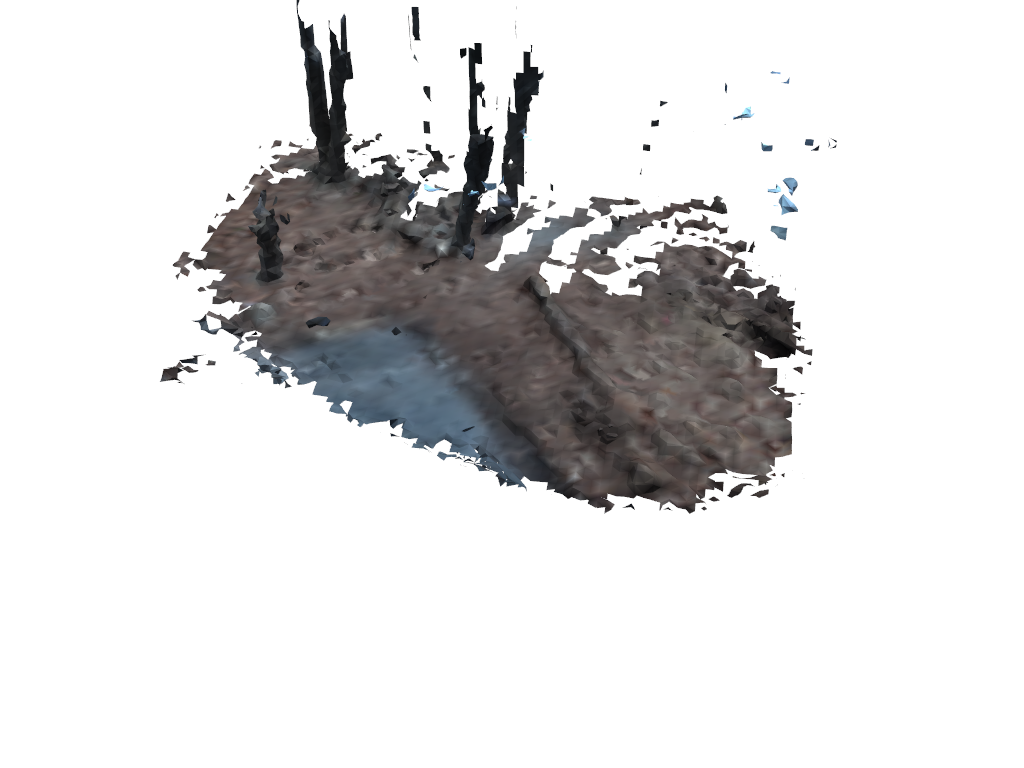

In [4]:
mesh_fn = splatter.config["mesh_info"]["mesh"].as_posix()

plotter = visualize_splat(
    mesh=mesh_fn,
    mesh_kwargs=MESH_KWARGS,
    viz_kwargs=VIZ_KWARGS,
)

plotter.show()

### Plot with camera frustums

Overlay the COLMAP camera poses used to fit the splat. Frustum appearance is controlled via `camera_kwargs`.

No transforms.pkl in /workspace/fieldwork-data/birds/2024-02-06/environment/C0043/rade-features/mesh — mesh is in nerfstudio world frame, using identity.


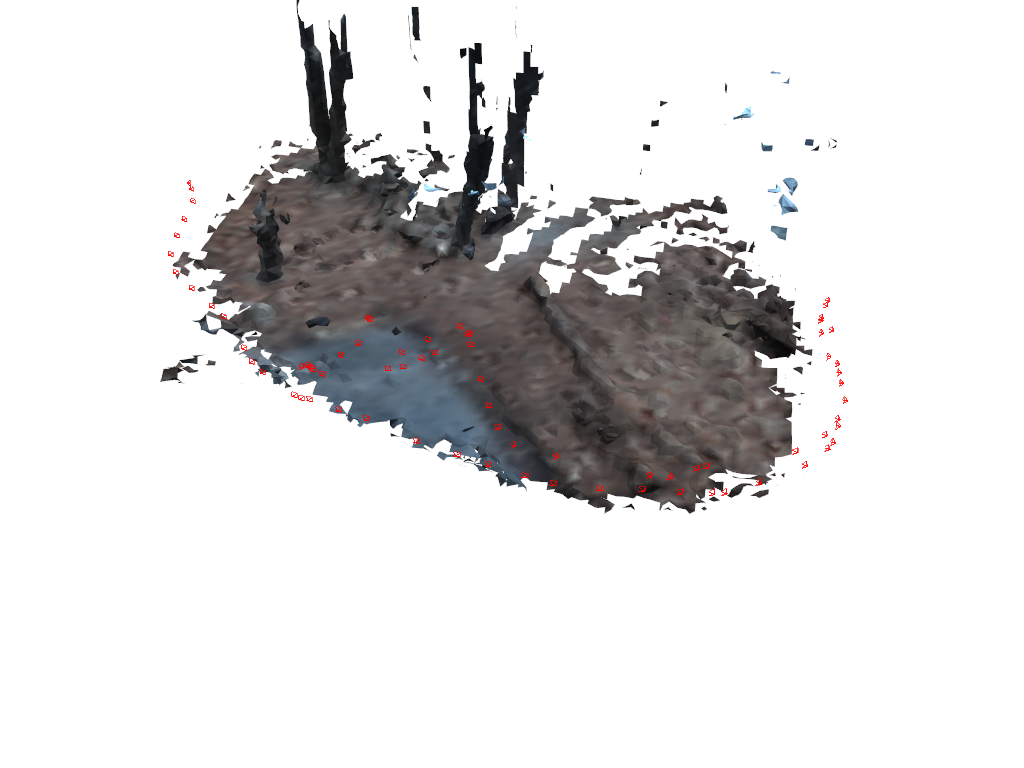

In [5]:
# Update the kwargs for how we want them to be shown
camera_kwargs = CAMERA_KWARGS.copy()
camera_kwargs.update(
    {
        "scale": 0.002,
        "color": "red",
        "line_width": 1,
        "opacity": 0.6,
        "n_poses": 8,
    }
)

# Load the aligned poses in case we want them for visualization --> by default they are aligned to the splat
aligned_cameras = splatter.load_aligned_cameras(align_mesh=True)

plotter = visualize_splat(
    mesh=splatter.config["mesh_info"]["mesh"].as_posix(),
    aligned_cameras=aligned_cameras,
    mesh_kwargs=MESH_KWARGS,
    camera_kwargs=camera_kwargs,
    viz_kwargs=VIZ_KWARGS,
)

plotter.show()

## §3 — Point-cloud visualization

The raw Gaussian splat point cloud is much denser and noisier than the mesh. We load the PLY directly via `plyfile` (pyvista/VTK skips custom float properties), convert SH DC coefficients to RGB, clean by distance, and transform into mesh frame.

In [6]:
# Load mesh transform and raw splat PLY
mesh_transform = splatter.load_mesh_transform()
pcd_fn = splatter.config["mesh_info"]["mesh"].parent / "splats.ply"

# Gaussian splat PLY stores colors as SH DC coefficients (f_dc_0/1/2).
# pyvista/VTK skips custom float properties, so read via plyfile.
# Convert: RGB = clip(0.5 + C0 * f_dc, 0, 1), C0 ≈ 0.2821
splat_raw = plyfile.PlyData.read(str(pcd_fn))["vertex"].data
pcd = o3d.geometry.PointCloud()
pcd.points = o3d.utility.Vector3dVector(
    np.stack([splat_raw["x"], splat_raw["y"], splat_raw["z"]], axis=1)
)
if "f_dc_0" in splat_raw.dtype.names:
    C0 = 0.28209479177387814
    rgb = np.clip(0.5 + C0 * np.stack([
        splat_raw["f_dc_0"],
        splat_raw["f_dc_1"],
        splat_raw["f_dc_2"],
    ], axis=1), 0, 1)
    pcd.colors = o3d.utility.Vector3dVector(rgb)

# Clean by distance from origin; preserve color, skip density/outlier removal
pcd, _ = clean_pcd(
    pcd, downsample=False, outlier_removal=False, distance_removal=True, reference="origin", max_distance=2.5
)

# Transform points into mesh coordinate frame
points = np.asarray(pcd.points)
points_homo = np.concatenate([points, np.ones((points.shape[0], 1))], axis=-1)
points_homo = mesh_transform["mesh_transform"] @ points_homo.T
points = points_homo.T[..., :-1]

No transforms.pkl in /workspace/fieldwork-data/birds/2024-02-06/environment/C0043/rade-features/mesh — mesh is in nerfstudio world frame, using identity.


### Render point cloud with PyVista

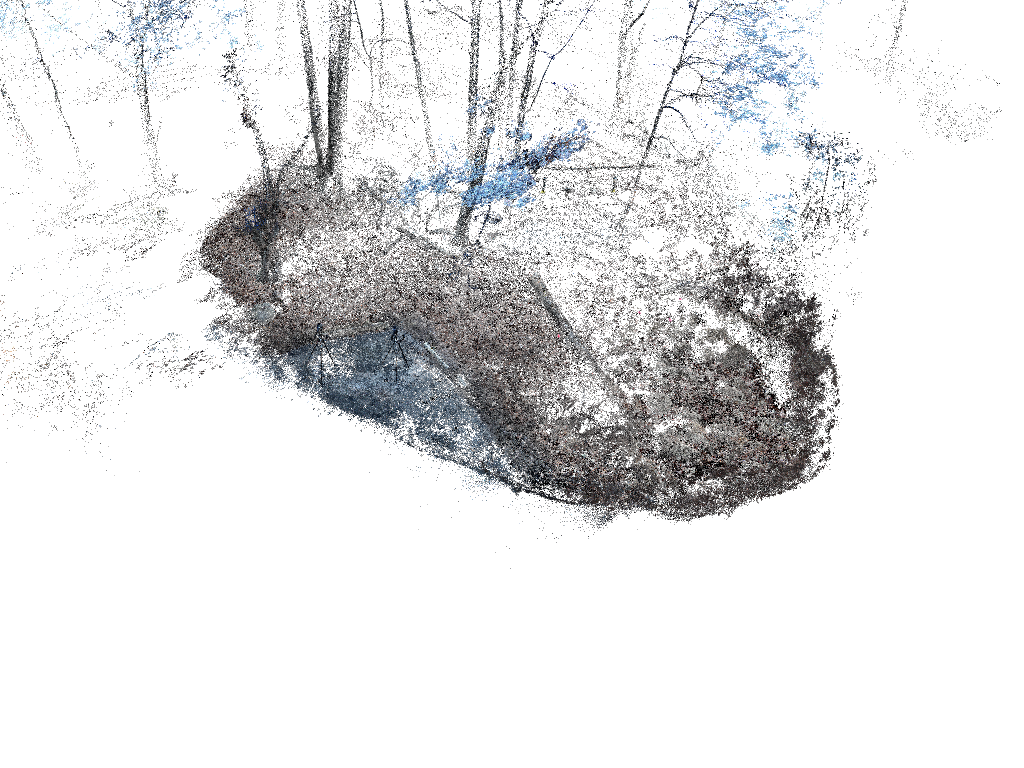

In [7]:
splat = pv.PolyData(points)
splat.point_data["RGB"] = np.asarray(pcd.colors)

pcd_kwargs = MESH_KWARGS.copy()
pcd_kwargs.update(
    {
        "point_size": 0.5,
        "render_points_as_spheres": True,
        "ambient": 0.3,
        "diffuse": 0.8,
        "specular": 0.1,
    }
)

plotter = visualize_splat(
    mesh=splat,
    mesh_kwargs=pcd_kwargs,
    viz_kwargs=VIZ_KWARGS,
)

plotter.show()

## §4 — Semantic query visualization

Visualize semantic query results: probability maps and binary masks. These PLY files are produced by `splatter.query()`; cells skip gracefully if they are absent.

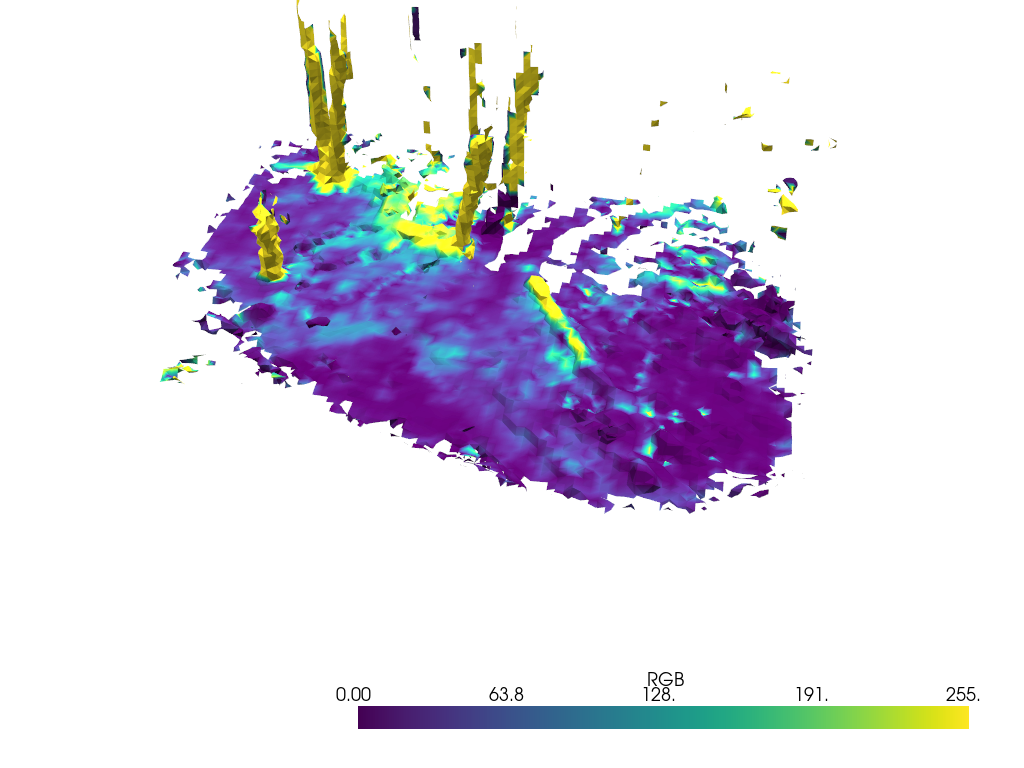

In [8]:
# Load the "tree" query
query_fn = splatter.config["mesh_info"]["mesh"].parent / "query-tree.ply"

if not query_fn.exists():
    print(f"query-tree.ply not found at {query_fn} — run splatter.query() first. Skipping.")
else:
    query_kwargs = MESH_KWARGS.copy()
    query_kwargs.update(
        {
            "rgb": False,
        }
    )

    plotter = visualize_splat(
        mesh=query_fn.as_posix(),
        mesh_kwargs=query_kwargs,
        viz_kwargs=VIZ_KWARGS,
    )

    plotter.show()

### Semantic segmentation mask

In [9]:
# Load the "tree" cluster segmentation
query_fn = splatter.config["mesh_info"]["mesh"].parent / "query-tree_top-cluster.ply"

if not query_fn.exists():
    print(f"query-tree_top-cluster.ply not found at {query_fn} — run splatter.query() first. Skipping.")
else:
    plotter = visualize_splat(
        mesh=query_fn.as_posix(),
        mesh_kwargs=MESH_KWARGS,
        viz_kwargs=VIZ_KWARGS,
    )

    plotter.show()

query-tree_top-cluster.ply not found at /workspace/fieldwork-data/birds/2024-02-06/environment/C0043/rade-features/mesh/query-tree_top-cluster.ply — run splatter.query() first. Skipping.


## §5 — Semantic feature visualization

Load per-point semantic feature vectors, apply PCA to reduce to 3 dimensions, and use the result as RGB. This gives a perceptually-meaningful coloring where similar regions share hues.

In [10]:
low_rank = None
features_fn = splatter.config["mesh_info"]["mesh"].parent / "mesh_features.pt"

if not features_fn.exists():
    print(f"mesh_features.pt not found at {features_fn} — run splatter.extract_features() first. Skipping.")
else:
    # Load feature tensor and centre before PCA
    features = torch.load(features_fn)
    mean = features.mean(0)

    # PCA: project to 3 components for RGB coloring
    n_iter = 5
    with torch.no_grad():
        U, S, V = torch.pca_lowrank(features - mean, niter=n_iter)
        proj_V = V[:, :3]

    # Normalise to [0, 1] using 1st/99th percentile to avoid outlier washout
    low_rank = features @ proj_V
    low_rank_min = torch.quantile(low_rank, 0.01, dim=0)
    low_rank_max = torch.quantile(low_rank, 0.99, dim=0)
    low_rank = (low_rank - low_rank_min) / (low_rank_max - low_rank_min)
    low_rank = torch.clamp(low_rank, 0, 1)

/tmp/ipykernel_1032834/1722811425.py:8: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  features = torch.load(features_fn)


### Render mesh coloured by PCA features

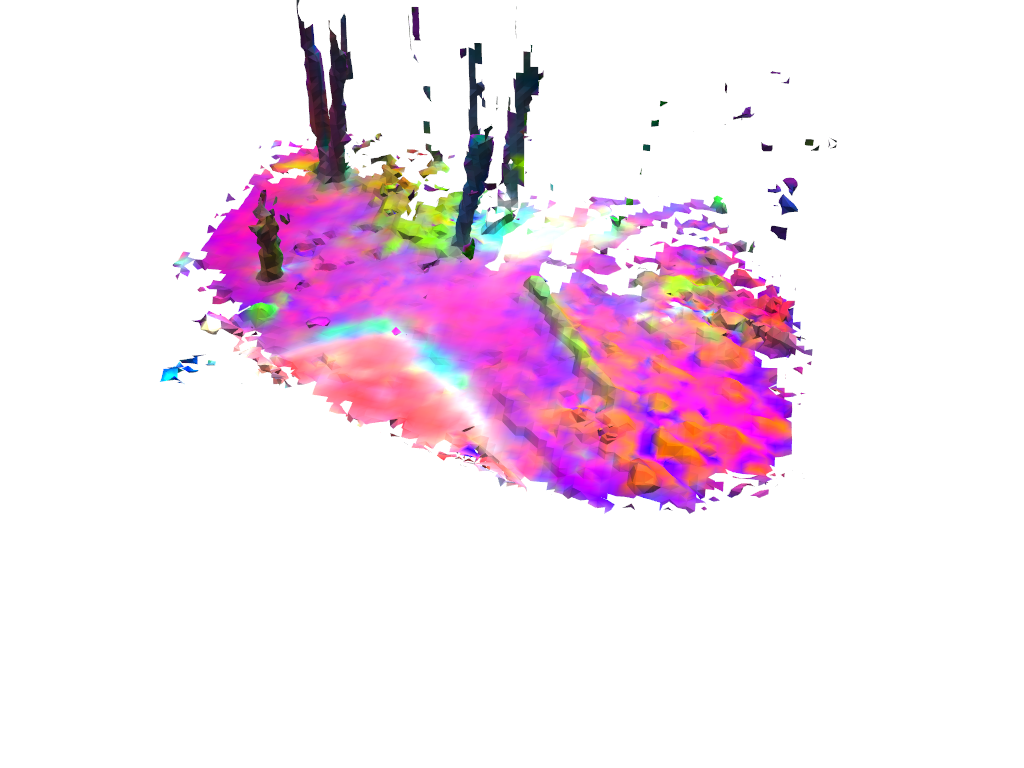

In [11]:
if low_rank is None:
    print("No features loaded — skipping feature visualization.")
else:
    mesh_fn = splatter.config["mesh_info"]["mesh"]
    mesh = pv.read(mesh_fn)

    mesh.point_data["features"] = low_rank

    features_kwargs = MESH_KWARGS.copy()
    features_kwargs.update(
        {
            "scalars": "features",
        }
    )

    plotter = visualize_splat(
        mesh=mesh,
        mesh_kwargs=features_kwargs,
        viz_kwargs=VIZ_KWARGS,
    )

    plotter.show()